In [1]:
from torch import Tensor, nn
import torch
import numpy as np

import os
import zarr
import s3fs
from torch.utils.data import Dataset
import torch
import torch.nn.functional as F


with open(os.path.expanduser("~") + "/.keys") as f:
    for line in f:
        if line.startswith("export "):
            key, val = line.strip().split("=", 1)
            os.environ[key.replace("export ","")] = val
fs = s3fs.S3FileSystem(
        key=os.environ["AWS_ACCESS_KEY_ID"],
        secret=os.environ["AWS_SECRET_ACCESS_KEY"],
        client_kwargs={"endpoint_url": "http://localhost:8333"}
    )

class LDCDataset(Dataset):
    def __init__(self, resolution, dimT):
        
        store_X = s3fs.S3Map(root="ldcdataset/ds2/X", s3=fs, check=False)
        store_Y = s3fs.S3Map(root="ldcdataset/ds2/Y", s3=fs, check=False)
        dts_X = zarr.open_array(store_X, mode="r")
        dts_Y = zarr.open_array(store_Y, mode="r")
        x = torch.from_numpy(dts_X[:])

        x = x.permute(0, 3, 1, 2)  # B C X X
        x = F.interpolate(x, size=(resolution, resolution), mode="bilinear", align_corners=False)
        x = x.permute(0, 2, 3, 1)  # B X X C
        self.X = x
        
        y = torch.from_numpy(dts_Y[:, :dimT])

        B, T, X, _, C = y.shape

        y = y.permute(0,1,4,2,3)  # B T C X X
        y = y.reshape(B*T, C, X, X)
        
        y = F.interpolate(y, size=(65,65), mode="bilinear", align_corners=False)
        
        y = y.reshape(B, T, C, 65, 65)
        y = y.permute(0,1,3,4,2)  # B T 65 65 C

        self.Y = y
        self.length = self.X.shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        return x, y


In [2]:
from sklearn.decomposition import PCA

dataset = LDCDataset(65, 100)
data_x = dataset.X


In [3]:
data_x = data_x[..., :3]

In [4]:
torch.mean(data_x)

tensor(0., dtype=torch.float64)

In [5]:
torch.var(data_x)

tensor(0., dtype=torch.float64)

In [6]:
data_x.shape

torch.Size([100, 65, 65, 3])

In [7]:
dataset.Y.shape

torch.Size([100, 100, 65, 65, 3])

In [8]:
B, X, _, C = data_x.shape
X_pca = data_x.reshape(B, X*X*C)

In [9]:
# X_pca = data_x.reshape(B, C*X*X)

In [10]:
pca = PCA()
Z = pca.fit_transform(X_pca)

/home/kz/vault/all-cfd/PINO/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


In [11]:
Z

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100))

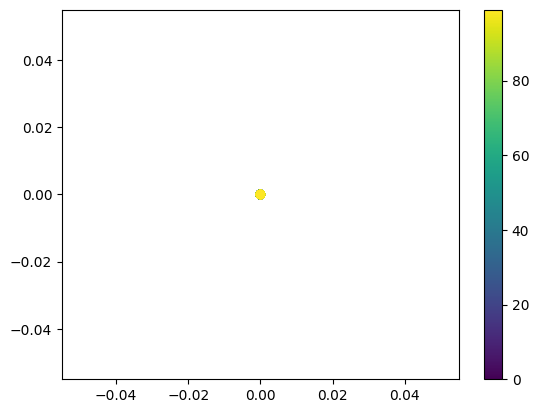

In [12]:
import matplotlib.pyplot as plt
plt.scatter(Z[:,0], Z[:,1], c=range(len(Z)))
plt.colorbar()
plt.show()

In [13]:
pca.explained_variance_ratio_

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan])

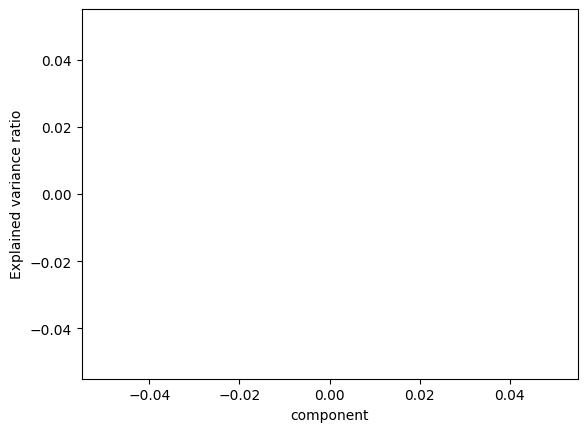

In [14]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("component")
plt.ylabel("Explained variance ratio")
plt.show()

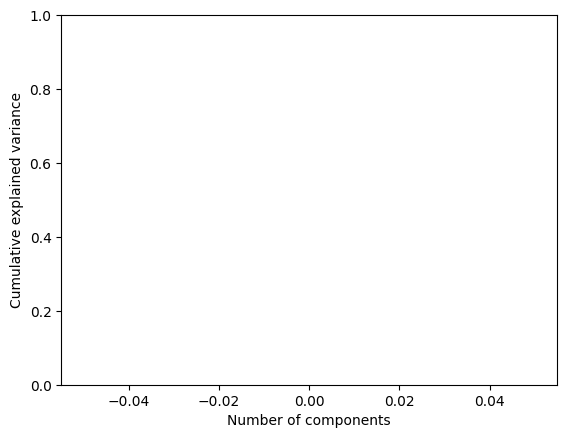

In [15]:

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0,1)
plt.show()

In [16]:
data_y = dataset.Y

In [17]:
data_y = data_y[:, :50]

In [18]:
data_y.shape

torch.Size([100, 50, 65, 65, 3])

In [32]:
torch.var(data_y)

tensor(0.0202, dtype=torch.float64)

In [33]:
torch.norm(data_y)

tensor(1131.8899, dtype=torch.float64)

In [34]:
torch.var(data_x)

tensor(0., dtype=torch.float64)

In [35]:
torch.norm(data_x)

tensor(0., dtype=torch.float64)

In [20]:
B, T, X, _, C = data_y.shape
Y_pca = data_y.reshape(B*T, X*X*C)

In [36]:
pca = PCA()
Z = pca.fit_transform(Y_pca)

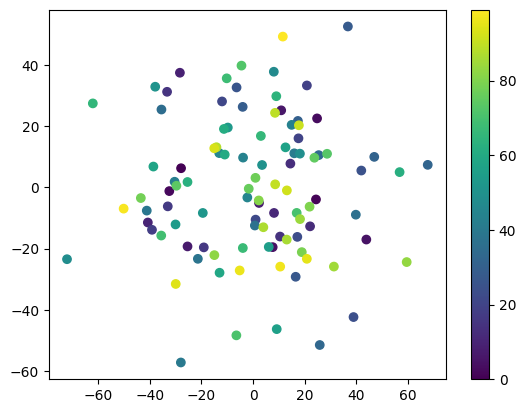

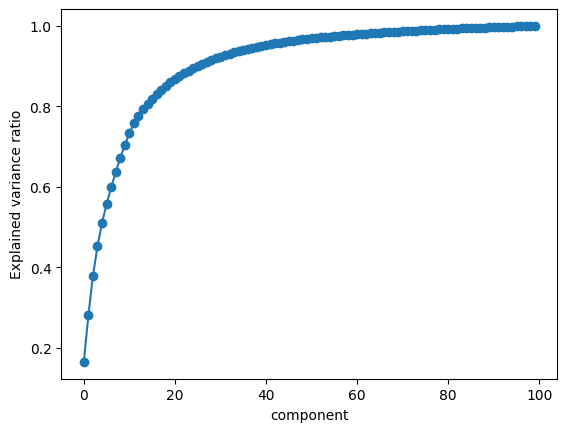

In [41]:
plt.scatter(Z[:,0], Z[:,1], c=range(len(Z)))
plt.colorbar()
plt.show()

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("component")
plt.ylabel("Explained variance ratio")
plt.show()

In [38]:
B, T, X, _, C = data_y.shape
Y_pca = data_y.reshape(B, T*X*X*C)

In [39]:
pca = PCA()
Z = pca.fit_transform(Y_pca)

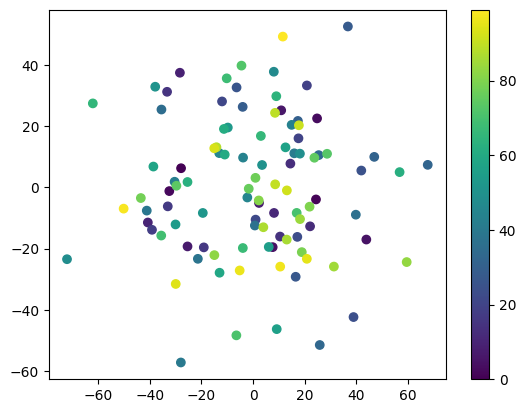

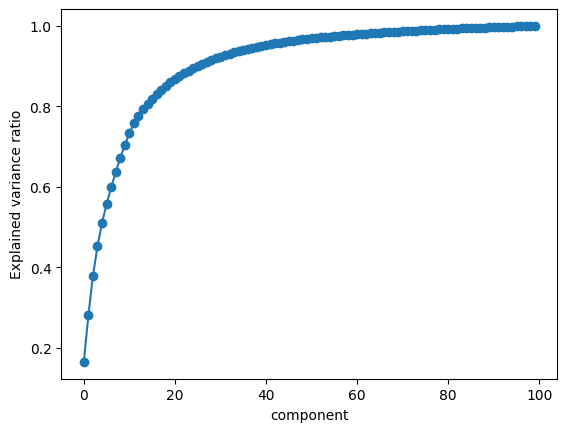

In [42]:
plt.scatter(Z[:,0], Z[:,1], c=range(len(Z)))
plt.colorbar()
plt.show()

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("component")
plt.ylabel("Explained variance ratio")
plt.show()

## Check pde loss on simulation

In [23]:
L2 = torch.nn.MSELoss(reduction="mean")
NU_LAYER = 3
T = (0, 10)
dimT = 100
alpha = 1
beta = 1
dim = 65
# re & nu not fixed

k = 1
dt = (T[1] - T[0]) / dimT
dx = 1.0 / dim
# residual loss over time
def residual_loss(a, u):
    # assumed density to be 1
    # v viscosity (nu)
    # du/dt = -(u.∇)u + v∇.∇u -∇p
    # R = du/dt + (u.∇)u + ∇p - v∇.∇u

    
    TRS = np.s_[:, 2:]  # Time restriction
    
    INT = np.s_[:, :, 1:-1, 1:-1, :]  # Interior
    XPO = np.s_[:, :,   2:, 1:-1, :]  # X Plus One
    XMO = np.s_[:, :,  :-2, 1:-1, :]  # X Minus One
    YPO = np.s_[:, :, 1:-1,   2:, :]  # Y Plus One
    YMO = np.s_[:, :, 1:-1,  :-2, :]  # Y Minus One 

    u_vel = u[..., :2]
    u_vel_t = u_vel[TRS]
    p_t = u[TRS][..., 2:2 + 1]
    
    nu = a[None][INT][..., NU_LAYER:NU_LAYER + 1]
    
    du_dt = (u_vel[INT][:, 2:] - u_vel[INT][:, 1:-1]) / dt
    
    du_dx = (u_vel_t[XPO] - u_vel_t[XMO]) / dx
    du_dy = (u_vel_t[YPO] - u_vel_t[YMO]) / dx
    du_dx2 = (u_vel_t[XPO] + u_vel_t[XMO] - 2 * u_vel_t[INT]) / (dx * dx)
    du_dy2 = (u_vel_t[YPO] + u_vel_t[YMO] - 2 * u_vel_t[INT]) / (dx * dx)
    dp_dx = (p_t[XPO] - p_t[XMO]) / dx
    dp_dy = (p_t[YPO] - p_t[YMO]) / dx
    
    c0 = u_vel_t[INT][..., 0] * du_dx[..., 0] + u_vel_t[INT][..., 1] * du_dy[..., 0]
    c1 = u_vel_t[INT][..., 0] * du_dx[..., 1] + u_vel_t[INT][..., 1] * du_dy[..., 1]
    convection = torch.stack([c0, c1], dim=-1)
    
    viscosity = nu * (du_dx2 + du_dy2)

    grad_p = torch.cat([dp_dx, dp_dy], dim=-1)
    
    R = du_dt + convection + grad_p - viscosity

    return torch.mean(R**2)

def batched_bcu(u):
    K = 1
    # top - slip
    u[..., 1:-1, 0, 0] = 2 * K - u[..., 1:-1, 1, 0]
    u[..., 1:-1, 0, 1] = - u[..., 1:-1, 1, 1]
    # bot - no slip
    u[..., 1:-1, -1, :] = - u[..., 1:-1, -2, :]
    # left - no slip
    u[..., 0, 1:-1, :] = - u[..., 1, 1:-1, :]
    # right - no slip
    u[..., -1, 1:-1, :] = - u[..., -2, 1:-1, :]


# boundary condition loss over time
def bc_loss(u):
    # compute BC
    
    u_vel = u[..., :2]
    bcu = u_vel.clone().detach()
    batched_bcu(bcu)
    return (
        L2(u_vel[:, :, 1:-1,    0, :], bcu[:, :, 1:-1,    0, :]) +
        L2(u_vel[:, :, 1:-1,   -1, :], bcu[:, :, 1:-1,   -1, :]) +
        L2(u_vel[:, :,    0, 1:-1, :], bcu[:, :,    0, 1:-1, :]) +
        L2(u_vel[:, :,   -1, 1:-1, :], bcu[:, :,   -1, 1:-1, :])
    )

# initial condition loss
def ic_loss(a, u):
    ic_vel = a[:, :, :, :2]
    u0_vel = u[:, 0, :, :, :2]
    return L2(ic_vel, u0_vel)

# L pde is J pde as long as loss is averaged over batch
def L_pde(a, pred):
    return residual_loss(a, pred) + alpha * bc_loss(pred) + beta * ic_loss(a, pred)

In [24]:
from torch.utils.data import DataLoader
dataset = LDCDataset(dim, dimT)
x, y = next(iter(DataLoader(dataset, batch_size=1, shuffle=False)))

In [25]:
y.shape

torch.Size([1, 100, 65, 65, 3])

In [26]:
L_pde(x, y)

tensor(2.1084, dtype=torch.float64)

In [27]:
L_pde(x, torch.rand(*y.shape))

tensor(1375.0703, dtype=torch.float64)

In [28]:
 residual_loss(x, y)

tensor(1.9656, dtype=torch.float64)

In [29]:
bc_loss(y)

tensor(0.1428, dtype=torch.float64)

In [30]:
ic_loss(x, y)

tensor(0., dtype=torch.float64)

In [31]:
import napari
viewer = napari.Viewer()
viewer.add_image(data_y[0].cpu(), name="y")
napari.run()